In [1]:
from May31_Frank2D_CPU import *

In [2]:
disk_name = 'AS209 1mm'
filename = 'uvtables/uvtable_AS209_continuum.npz'
disk_geometry = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3 }
Rout = 1.2*2
N = 300
maxiter= 20000
rtol = 1e-10

print("Running: " + disk_name +" ...." + " frank2d model with " + str(N)+ 'x'+str(N)+ " points" )

Running: AS209 1mm .... frank2d model with 300x300 points


In [3]:
inc = disk_geometry['inc']
pa = disk_geometry['pa']
dra = disk_geometry['dra']
ddec = disk_geometry['ddec']

# UVtable
dir = "../../../data/"
data_file = dir + filename

 # load data
data = np.load(data_file)
u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
Vis = Re + Imag*1j

u, v, Vis, Weights =  u, v, Vis, Weights


geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_gridded_matrix


Enforcing Hermitian symmetry...
  --> time = 0.24  min |  14.26 seconds
Setting gridded data...


In [4]:
from frank.radial_fitters import FrankFitter
from frank.geometry import SourceGeometry

alpha = 1.3
w_smooth = 1e-3
n_pts = 300

geom_f1d = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(Rout, n_pts, geom_f1d, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_gridded, v_gridded, vis_gridded, weights_gridded)

/opt/anaconda3/lib/python3.12/site-packages/frank/statistical_models.py:218: RuntimeWarning: divide by zero encountered in log
  H0 = 0.5 * np.sum(np.log(w / (2 * np.pi)) - V * w * V)
/opt/anaconda3/lib/python3.12/site-packages/frank/filter.py:175: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  tau = scipy.sparse.linalg.spsolve(Tij_pI, beta + np.log(pi))


In [5]:
vis_fit_1d = sol.predict(u_gridded, v_gridded, sol.mean, geometry = geom_f1d)

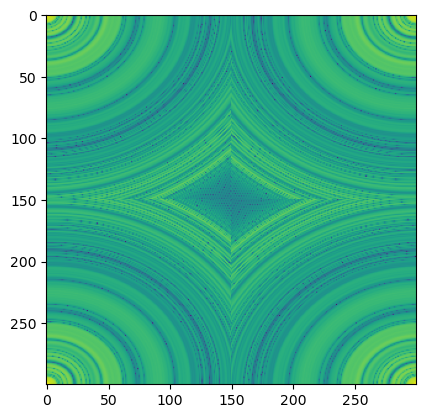

In [6]:
plt.imshow(np.log(np.abs(vis_fit_1d.reshape(N, N))))

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_80028/1520320944.py:3: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(N, N)))), extent=extent, origin='lower', vmin=-8, vmax=-1, cmap = 'viridis')


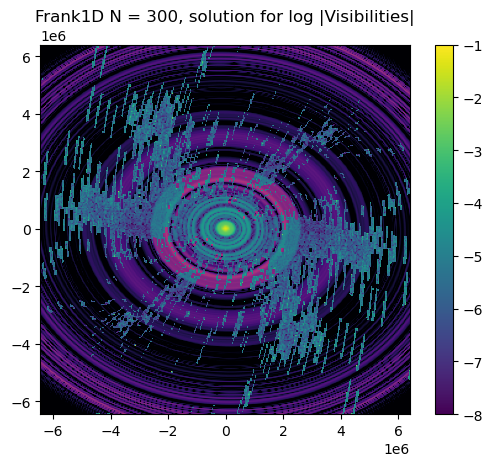

In [7]:
extent=[u_gridded.min(), u_gridded.max(), v_gridded.min(), v_gridded.max()]
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_fit_1d.real.reshape(N, N)))), extent=extent, origin='lower', vmin=-8, vmax=-1, cmap='magma')
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(N, N)))), extent=extent, origin='lower', vmin=-8, vmax=-1, cmap = 'viridis')
plt.title(f'Frank1D N = {N}, solution for log |Visibilities|')
plt.colorbar()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_80028/2256721134.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(N, N)))), extent=extent, origin='lower', vmin=-12, vmax=-2)


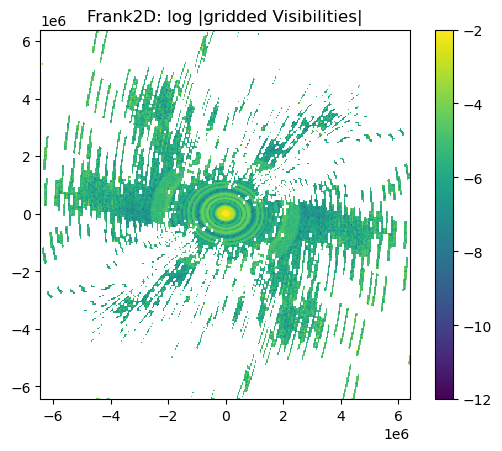

In [8]:
plt.figure()
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(N, N)))), extent=extent, origin='lower', vmin=-12, vmax=-2)
plt.title(f'Frank2D: log |gridded Visibilities|')
plt.colorbar()

RUNNING WITH  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
DATA (90000,)
------> Creating linear operators
  --> time = 4.22  min |  253.39 seconds
---------------------------------
------> Creating sparse system
  --> time = 1.42  min |  85.34 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.2881751982790493
....................... TOLERANCE:  0.2881751982790493
         * maxiter:  20000
.... iteration:  0
                        -> actual tol:  238025809.63800776 vs  0.2881751982790493
.... iteration:  1
                        -> actual tol:  39734070.48675084 vs  0.2881751982790493
.... iteration:  2
                        -> actual tol:  27902070.178385872 vs  0.2881751982790493
.... iteration:  3
                        -> actual tol:  107248019.41877298 vs  0.2881751982790493
.... iteration:  4
                        -> actual tol:  18706287.534440756 vs  0.2881751982790493
.... iteration:  5
    

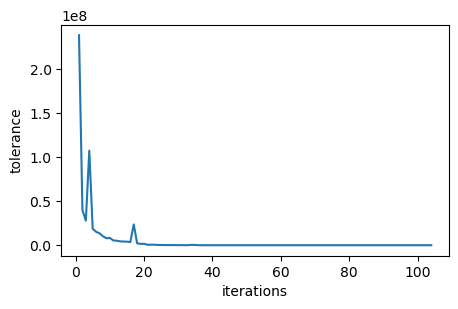

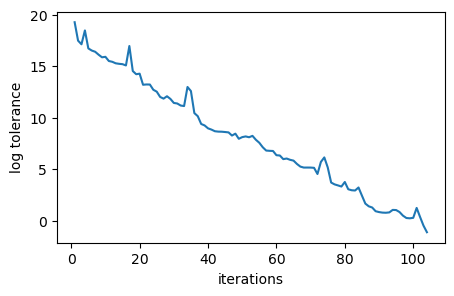

CGM with info:  0
  --> time = 0.04  min |  2.42 seconds
---------------------------------
------> CGM converged?   True
              --> Fit correctly?   True
                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!
---------------------------------
Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds
  ------------------------------------------> TOTAL ALGORITHM TIME = 5.69  min |  341.21 seconds


In [11]:
start_time = time.time()

frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']
sol = Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded,
                        maxiter = maxiter, rtol = rtol, 
                        kernel_params = {'m': -2, 'c': 1e8, 'l': 5e4}, 
                        x0 = vis_fit_1d)
frank2d.sol_visibility = sol
frank2d.fft()

end_time = time.time()
execution_time = end_time - start_time
print(f'  ------------------------------------------> TOTAL ALGORITHM TIME = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
